# Customer Churn Prediction
## Preprocessing Technique 04 — Class Imbalance Handling
**Member: Sipna**

This notebook handles the class imbalance in the churn target variable `Exited`.

### Input
`03_outlier_removed_churn_data.csv`

### Target meaning
- `Exited = 0` → Customer stayed
- `Exited = 1` → Customer churned

### Main tasks
- Inspect the class distribution
- Visualize imbalance before balancing
- Calculate class counts and percentages
- Handle imbalance using **Random Oversampling**
- Visualize the balanced classes
- Compare before vs after balancing
- Demonstrate a leakage-safe train/test balancing workflow
- Save the balanced output for the next preprocessing stage


## Why Random Oversampling?

After categorical encoding, the dataset contains several binary/dummy variables such as:

- `Gender`
- `HasCrCard`
- `IsActiveMember`
- `Geography_Germany`
- `Geography_Spain`

For this standalone preprocessing stage, **RandomOverSampler** is used because it balances the minority class by duplicating existing minority-class records and therefore preserves valid 0/1 encoded values.

This avoids creating fractional dummy values that can occur when ordinary SMOTE is directly applied to one-hot encoded variables.


In [1]:
# Import libraries

import sys
import subprocess
import importlib.util

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display

from sklearn.model_selection import train_test_split

# Install imbalanced-learn only if it is not already available
if importlib.util.find_spec("imblearn") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "imbalanced-learn"]
    )

from imblearn.over_sampling import RandomOverSampler

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load the Outlier-Removed Dataset

This notebook is the fourth stage of the group preprocessing workflow.

It first looks for:

`03_outlier_removed_churn_data.csv`

If that file is not available, it can temporarily use the encoded output from Notebook 02.


In [2]:
from google.colab import files

uploaded = files.upload()

Saving 03_outlier_removed_churn_data.csv to 03_outlier_removed_churn_data.csv


In [3]:
possible_paths = [
    Path("/content/03_outlier_removed_churn_data.csv"),
    Path("03_outlier_removed_churn_data.csv"),
    Path("/content/02_encoded_churn_data.csv"),
    Path("02_encoded_churn_data.csv")
]

file_path = None

for path in possible_paths:
    if path.exists():
        file_path = path
        break

if file_path is None:
    raise FileNotFoundError(
        "03_outlier_removed_churn_data.csv was not found. "
        "Run Notebook 03 - Outlier Removal first, "
        "or upload its output CSV."
    )

df = pd.read_csv(file_path)

print("Loaded file:", file_path)
print("Dataset shape:", df.shape)

df.head()


Loaded file: /content/03_outlier_removed_churn_data.csv
Dataset shape: (9568, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


## 2. Initial Dataset Inspection


In [4]:
print("Dataset Information")
print("-" * 60)
df.info()

print("\nMissing values:")
display(df.isnull().sum().to_frame(name="Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget values:")
print(df["Exited"].value_counts().sort_index())


Dataset Information
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        9568 non-null   int64  
 1   Gender             9568 non-null   int64  
 2   Age                9568 non-null   int64  
 3   Tenure             9568 non-null   int64  
 4   Balance            9568 non-null   float64
 5   NumOfProducts      9568 non-null   int64  
 6   HasCrCard          9568 non-null   int64  
 7   IsActiveMember     9568 non-null   int64  
 8   EstimatedSalary    9568 non-null   float64
 9   Exited             9568 non-null   int64  
 10  Geography_Germany  9568 non-null   int64  
 11  Geography_Spain    9568 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 897.1 KB

Missing values:


,Missing Values
CreditScore,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0
Exited,0



Duplicate rows: 0

Target values:
Exited
0    7677
1    1891
Name: count, dtype: int64


## 3. Check Class Distribution Before Balancing

The target distribution is calculated using both counts and percentages.


In [5]:
class_counts_before = (
    df["Exited"]
    .value_counts()
    .sort_index()
)

class_percent_before = (
    df["Exited"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

class_summary_before = pd.DataFrame({
    "Class": class_counts_before.index,
    "Count": class_counts_before.values,
    "Percentage": class_percent_before.values
})

display(class_summary_before.round(2))


,Class,Count,Percentage
0,0,7677,80.24
1,1,1891,19.76


## 4. EDA — Class Distribution Before Balancing

A count plot clearly shows whether one target class has substantially more records than the other.


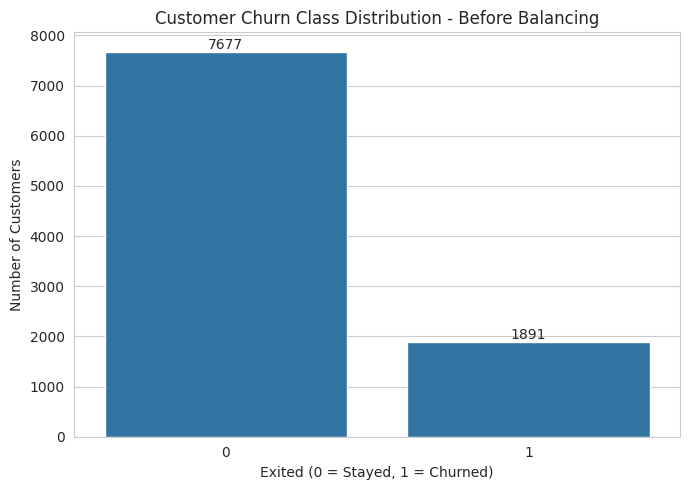

In [6]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Exited"
)

plt.title("Customer Churn Class Distribution - Before Balancing")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


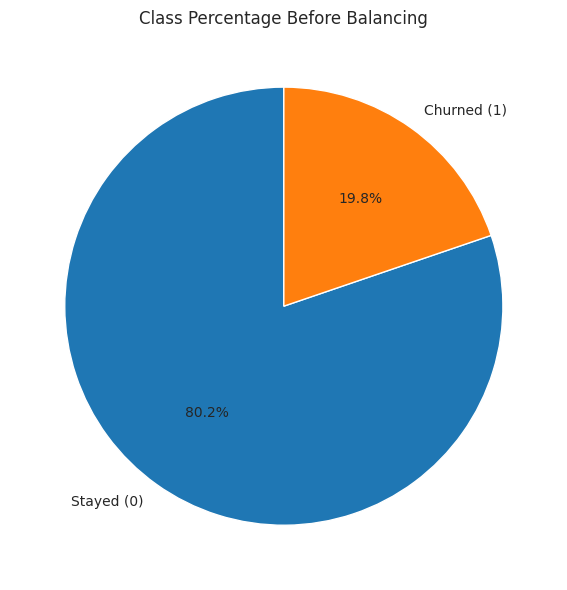

In [7]:
plt.figure(figsize=(6, 6))

labels = [
    "Stayed (0)",
    "Churned (1)"
]

values = [
    class_counts_before.get(0, 0),
    class_counts_before.get(1, 0)
]

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Class Percentage Before Balancing")
plt.tight_layout()
plt.show()


## 5. Measure the Imbalance

The imbalance ratio compares the majority-class size with the minority-class size.

A ratio greater than 1 indicates that the target classes are not equally represented.


In [8]:
majority_count = class_counts_before.max()
minority_count = class_counts_before.min()

imbalance_ratio = majority_count / minority_count

print("Majority class count :", majority_count)
print("Minority class count :", minority_count)
print(f"Imbalance ratio      : {imbalance_ratio:.2f} : 1")


Majority class count : 7677
Minority class count : 1891
Imbalance ratio      : 4.06 : 1


## 6. Separate Features and Target


In [9]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

print("Feature shape:", X.shape)
print("Target shape :", y.shape)

print("\nTarget distribution:")
print(y.value_counts().sort_index())


Feature shape: (9568, 11)
Target shape : (9568,)

Target distribution:
Exited
0    7677
1    1891
Name: count, dtype: int64


## 7. Apply Random Oversampling

`RandomOverSampler` increases the minority class until it matches the majority class.

`random_state=42` is used so that the result is reproducible.


In [10]:
ros = RandomOverSampler(
    sampling_strategy="auto",
    random_state=42
)

X_balanced, y_balanced = ros.fit_resample(
    X,
    y
)

print("Balancing completed successfully!")

print("\nBefore balancing:")
print(y.value_counts().sort_index())

print("\nAfter balancing:")
print(y_balanced.value_counts().sort_index())


Balancing completed successfully!

Before balancing:
Exited
0    7677
1    1891
Name: count, dtype: int64

After balancing:
Exited
0    7677
1    7677
Name: count, dtype: int64


## 8. Recreate the Balanced Dataset


In [11]:
df_balanced = X_balanced.copy()

df_balanced["Exited"] = y_balanced.values

print("Original dataset shape:", df.shape)
print("Balanced dataset shape:", df_balanced.shape)

df_balanced.head()


Original dataset shape: (9568, 12)
Balanced dataset shape: (15354, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Exited
0,619,0,42,2,0.00,1,1,1,101348.88,0,0,1
1,608,0,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,0,42,8,159660.80,3,1,0,113931.57,0,0,1
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,1,0


## 9. EDA — Class Distribution After Balancing


In [12]:
class_counts_after = (
    df_balanced["Exited"]
    .value_counts()
    .sort_index()
)

class_percent_after = (
    df_balanced["Exited"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

class_summary_after = pd.DataFrame({
    "Class": class_counts_after.index,
    "Count": class_counts_after.values,
    "Percentage": class_percent_after.values
})

display(class_summary_after.round(2))


,Class,Count,Percentage
0,0,7677,50.0
1,1,7677,50.0


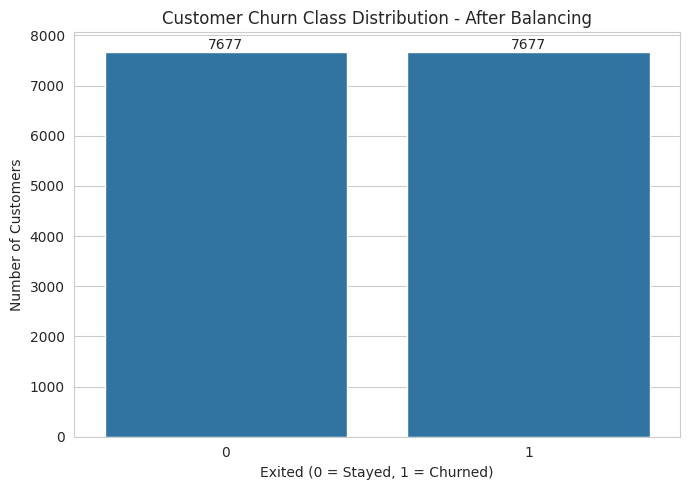

In [13]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_balanced,
    x="Exited"
)

plt.title("Customer Churn Class Distribution - After Balancing")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


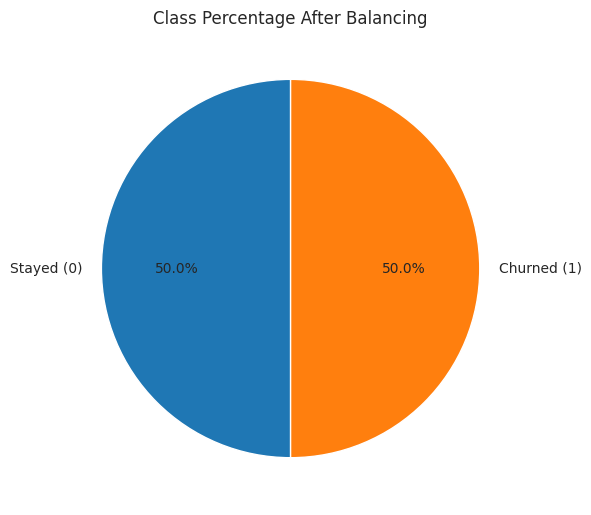

In [14]:
plt.figure(figsize=(6, 6))

labels = [
    "Stayed (0)",
    "Churned (1)"
]

values = [
    class_counts_after.get(0, 0),
    class_counts_after.get(1, 0)
]

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Class Percentage After Balancing")
plt.tight_layout()
plt.show()


## 10. Before vs After Class Comparison


In [15]:
comparison = pd.DataFrame({
    "Class": [0, 1],

    "Before Count": [
        class_counts_before.get(0, 0),
        class_counts_before.get(1, 0)
    ],

    "After Count": [
        class_counts_after.get(0, 0),
        class_counts_after.get(1, 0)
    ],

    "Before Percentage": [
        class_percent_before.get(0, 0),
        class_percent_before.get(1, 0)
    ],

    "After Percentage": [
        class_percent_after.get(0, 0),
        class_percent_after.get(1, 0)
    ]
})

display(comparison.round(2))


,Class,Before Count,After Count,Before Percentage,After Percentage
0,0,7677,7677,80.24,50.0
1,1,1891,7677,19.76,50.0


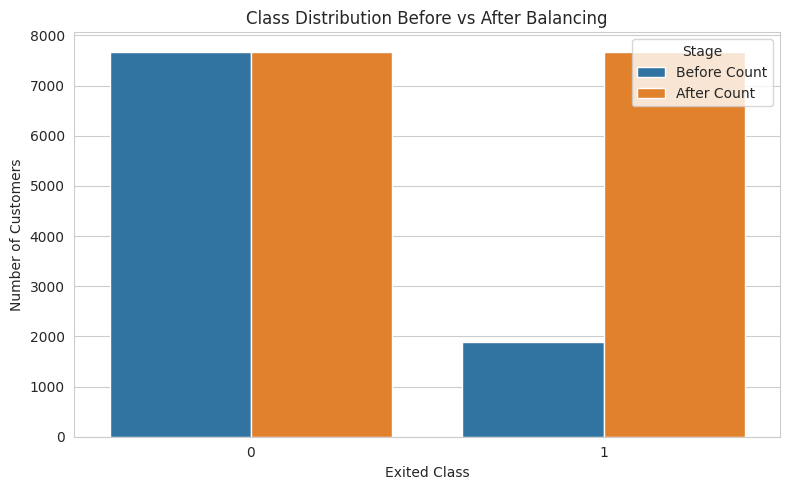

In [16]:
comparison_long = comparison.melt(
    id_vars="Class",
    value_vars=["Before Count", "After Count"],
    var_name="Stage",
    value_name="Count"
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_long,
    x="Class",
    y="Count",
    hue="Stage"
)

plt.title("Class Distribution Before vs After Balancing")
plt.xlabel("Exited Class")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


## 11. EDA — Selected Feature Distributions Before vs After Balancing

Oversampling changes the number of observations but should preserve the overall meaning of the original feature values because existing minority-class rows are duplicated.


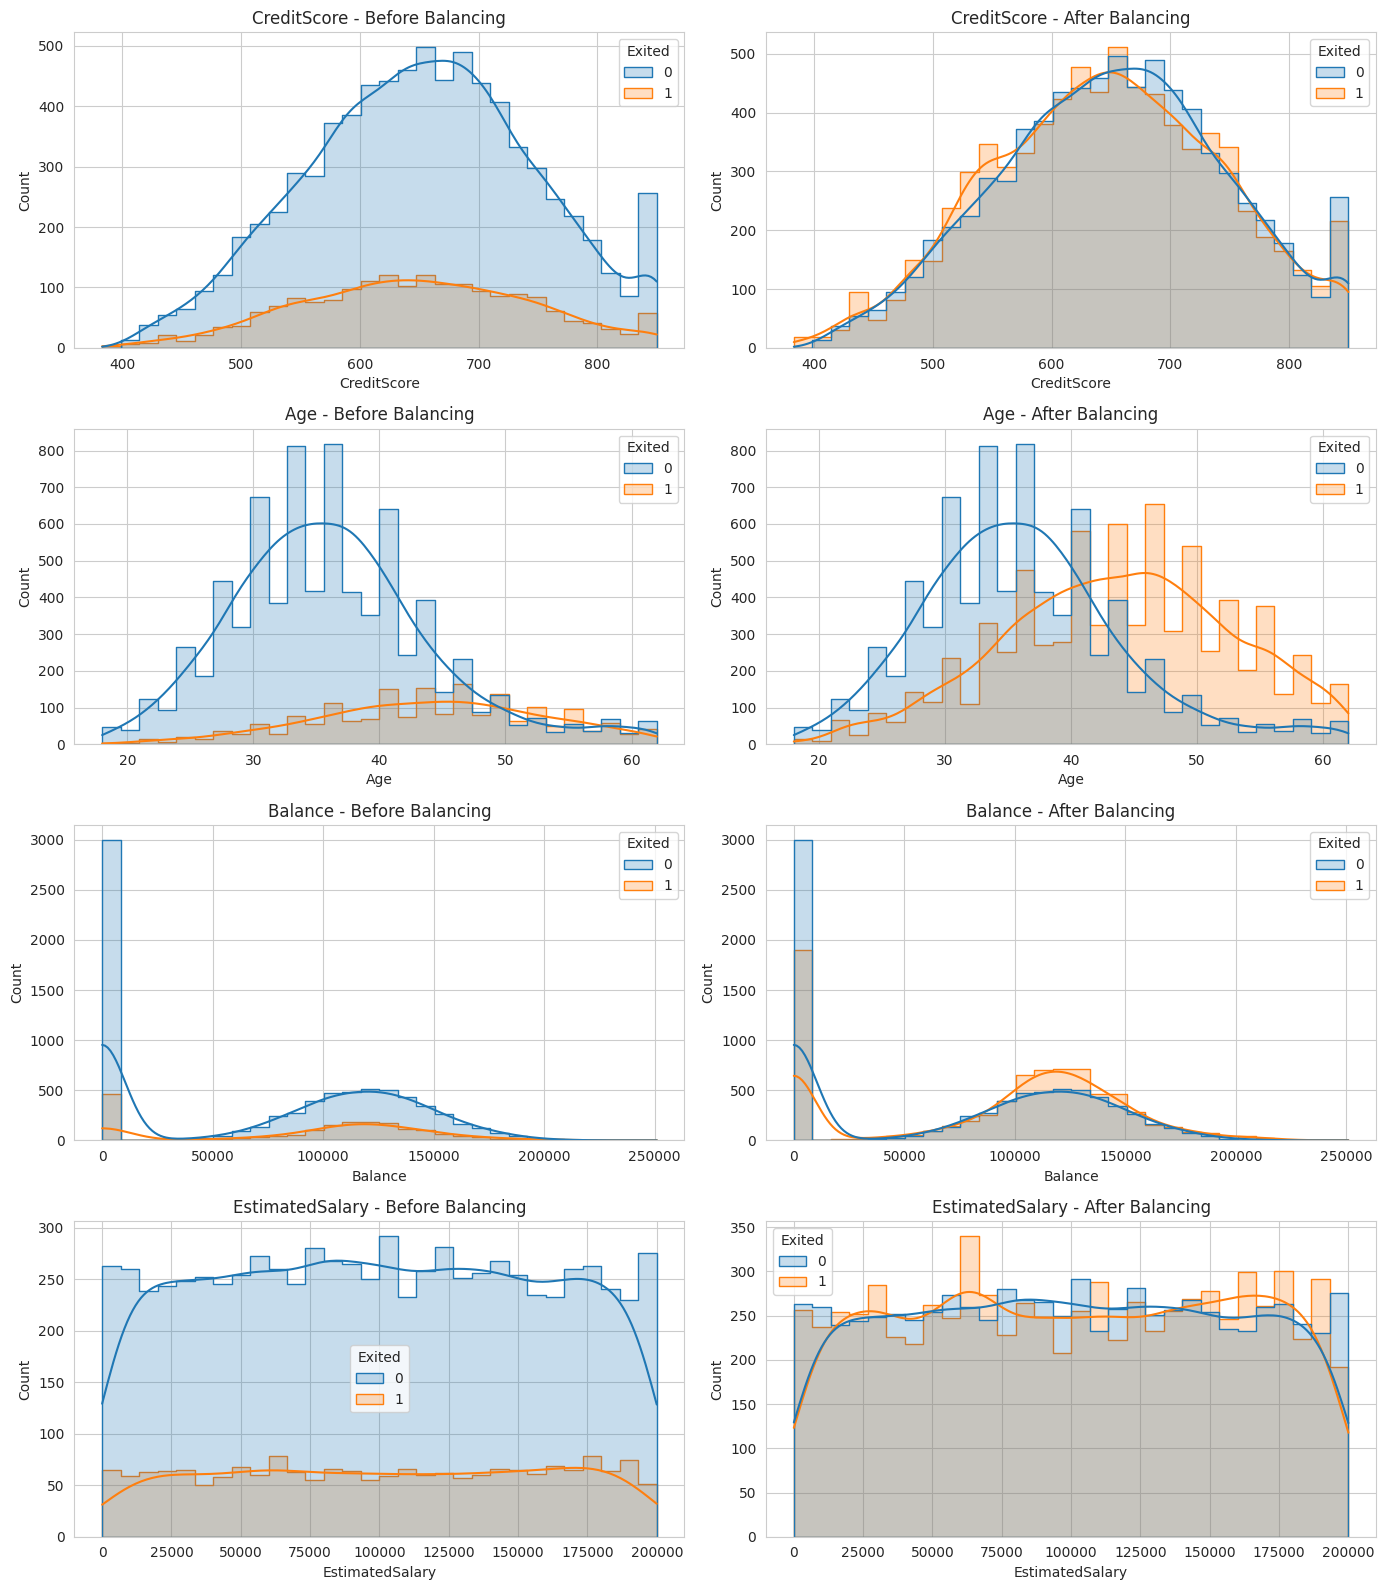

In [17]:
eda_features = [
    col for col in [
        "CreditScore",
        "Age",
        "Balance",
        "EstimatedSalary"
    ]
    if col in df.columns
]

fig, axes = plt.subplots(
    len(eda_features),
    2,
    figsize=(14, 4 * len(eda_features))
)

if len(eda_features) == 1:
    axes = np.array([axes])

for i, col in enumerate(eda_features):

    sns.histplot(
        data=df,
        x=col,
        hue="Exited",
        bins=30,
        kde=True,
        element="step",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(
        f"{col} - Before Balancing"
    )

    sns.histplot(
        data=df_balanced,
        x=col,
        hue="Exited",
        bins=30,
        kde=True,
        element="step",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(
        f"{col} - After Balancing"
    )

plt.tight_layout()
plt.show()


## 12. Check Binary / Dummy Values After Oversampling

Because Random Oversampling duplicates existing records instead of creating interpolated synthetic values, binary and one-hot encoded features should remain valid 0/1 values.


In [18]:
binary_columns = [
    col for col in df_balanced.columns
    if (
        col in [
            "Gender",
            "HasCrCard",
            "IsActiveMember"
        ]
        or col.startswith("Geography_")
    )
]

binary_validation = []

for col in binary_columns:
    unique_values = sorted(
        df_balanced[col]
        .dropna()
        .unique()
        .tolist()
    )

    binary_validation.append({
        "Feature": col,
        "Unique Values After Balancing": unique_values
    })

display(
    pd.DataFrame(binary_validation)
)


,Feature,Unique Values After Balancing
0,Gender,"[0, 1]"
1,HasCrCard,"[0, 1]"
2,IsActiveMember,"[0, 1]"
3,Geography_Germany,"[0, 1]"
4,Geography_Spain,"[0, 1]"


## 13. Validation After Balancing


In [19]:
print("Balanced dataset shape:", df_balanced.shape)

print("\nTotal missing values:")
print(df_balanced.isnull().sum().sum())

print("\nClass distribution:")
print(
    df_balanced["Exited"]
    .value_counts()
    .sort_index()
)

print("\nClass percentages:")
print(
    (
        df_balanced["Exited"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)


Balanced dataset shape: (15354, 12)

Total missing values:
0

Class distribution:
Exited
0    7677
1    7677
Name: count, dtype: int64

Class percentages:
Exited
0    50.0
1    50.0
Name: proportion, dtype: float64


# Important: Leakage-Safe Method for Model Training

For actual machine-learning model development, **do not oversample the full dataset before the train/test split**.

Correct procedure:

1. Split the original processed dataset into training and test sets.
2. Apply oversampling only to the **training set**.
3. Keep the test set unchanged.
4. Train the model using the balanced training set.
5. Evaluate on the untouched test set.

This prevents information from the test set from leaking into the training process.


## 14. Train/Test Split Before Oversampling


In [20]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)

print("\nTraining target distribution BEFORE balancing:")
print(y_train.value_counts().sort_index())

print("\nTest target distribution - kept untouched:")
print(y_test.value_counts().sort_index())


Training feature shape: (7654, 11)
Testing feature shape : (1914, 11)

Training target distribution BEFORE balancing:
Exited
0    6141
1    1513
Name: count, dtype: int64

Test target distribution - kept untouched:
Exited
0    1536
1     378
Name: count, dtype: int64


## 15. Apply Oversampling Only to Training Data


In [21]:
ros_train = RandomOverSampler(
    random_state=42
)

X_train_balanced, y_train_balanced = (
    ros_train.fit_resample(
        X_train,
        y_train
    )
)

print("Training distribution BEFORE balancing:")
print(y_train.value_counts().sort_index())

print("\nTraining distribution AFTER balancing:")
print(y_train_balanced.value_counts().sort_index())

print("\nTest distribution remains unchanged:")
print(y_test.value_counts().sort_index())


Training distribution BEFORE balancing:
Exited
0    6141
1    1513
Name: count, dtype: int64

Training distribution AFTER balancing:
Exited
0    6141
1    6141
Name: count, dtype: int64

Test distribution remains unchanged:
Exited
0    1536
1     378
Name: count, dtype: int64


,Class,Training Before,Training After
0,0,6141,6141
1,1,1513,6141


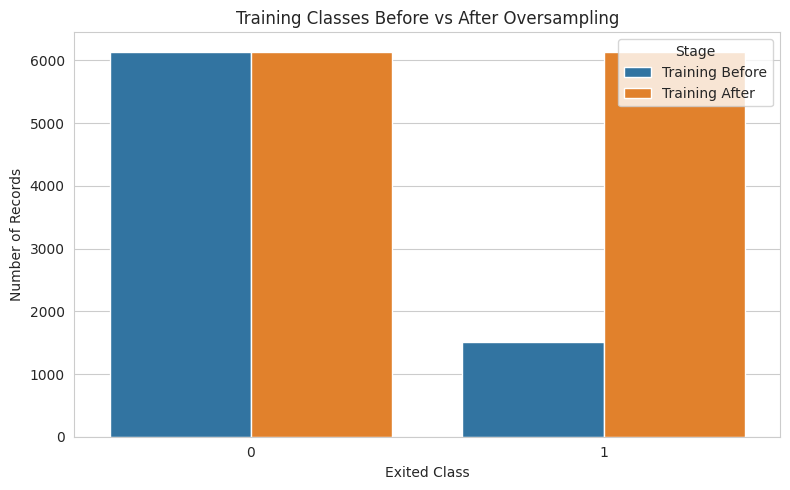

In [22]:
train_before = (
    y_train
    .value_counts()
    .sort_index()
)

train_after = (
    y_train_balanced
    .value_counts()
    .sort_index()
)

train_balance_comparison = pd.DataFrame({
    "Class": [0, 1],
    "Training Before": [
        train_before.get(0, 0),
        train_before.get(1, 0)
    ],
    "Training After": [
        train_after.get(0, 0),
        train_after.get(1, 0)
    ]
})

display(train_balance_comparison)

plot_df = train_balance_comparison.melt(
    id_vars="Class",
    value_vars=[
        "Training Before",
        "Training After"
    ],
    var_name="Stage",
    value_name="Count"
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=plot_df,
    x="Class",
    y="Count",
    hue="Stage"
)

plt.title("Training Classes Before vs After Oversampling")
plt.xlabel("Exited Class")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()


## 16. Create Leakage-Safe Training and Test Outputs

The balanced training dataset and untouched test dataset are saved separately.

These files are the safer choice for later model development.


In [23]:
train_balanced_df = X_train_balanced.copy()
train_balanced_df["Exited"] = y_train_balanced.values

test_original_df = X_test.copy()
test_original_df["Exited"] = y_test.values

print("Balanced training shape:", train_balanced_df.shape)
print("Untouched test shape   :", test_original_df.shape)


Balanced training shape: (12282, 12)
Untouched test shape   : (1914, 12)


## 17. Save the Balanced Dataset

For the six-notebook preprocessing workflow, the full balanced demonstration output is saved as:

`04_balanced_churn_data.csv`

For leakage-safe model development, two additional outputs are also saved:

- `04_train_balanced.csv`
- `04_test_original.csv`

The next individual notebook, **Feature Engineering**, can use `04_balanced_churn_data.csv` for the sequential preprocessing demonstration.


In [24]:
base_dir = Path("/content") if Path("/content").exists() else Path(".")

full_output = base_dir / "04_balanced_churn_data.csv"
train_output = base_dir / "04_train_balanced.csv"
test_output = base_dir / "04_test_original.csv"

df_balanced.to_csv(
    full_output,
    index=False
)

train_balanced_df.to_csv(
    train_output,
    index=False
)

test_original_df.to_csv(
    test_output,
    index=False
)

print("Files saved successfully!")
print("\nSequential preprocessing output:")
print(full_output)

print("\nLeakage-safe model-development outputs:")
print(train_output)
print(test_output)


Files saved successfully!

Sequential preprocessing output:
/content/04_balanced_churn_data.csv

Leakage-safe model-development outputs:
/content/04_train_balanced.csv
/content/04_test_original.csv


In [25]:
# Optional Google Colab downloads

try:
    from google.colab import files

    files.download(str(full_output))
    files.download(str(train_output))
    files.download(str(test_output))

except ImportError:
    print(
        "Google Colab download is not available "
        "in this environment."
    )


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Before vs After Summary


In [26]:
summary = pd.DataFrame({
    "Measure": [
        "Number of Rows",
        "Number of Columns",
        "Class 0 Count",
        "Class 1 Count",
        "Class 0 Percentage",
        "Class 1 Percentage",
        "Total Missing Values"
    ],

    "Before Balancing": [
        df.shape[0],
        df.shape[1],
        class_counts_before.get(0, 0),
        class_counts_before.get(1, 0),
        class_percent_before.get(0, 0),
        class_percent_before.get(1, 0),
        df.isnull().sum().sum()
    ],

    "After Balancing": [
        df_balanced.shape[0],
        df_balanced.shape[1],
        class_counts_after.get(0, 0),
        class_counts_after.get(1, 0),
        class_percent_after.get(0, 0),
        class_percent_after.get(1, 0),
        df_balanced.isnull().sum().sum()
    ]
})

display(summary.round(2))


,Measure,Before Balancing,After Balancing
0,Number of Rows,9568.00,15354.0
1,Number of Columns,12.00,12.0
2,Class 0 Count,7677.00,7677.0
3,Class 1 Count,1891.00,7677.0
4,Class 0 Percentage,80.24,50.0
5,Class 1 Percentage,19.76,50.0
6,Total Missing Values,0.00,0.0


In [27]:
from google.colab import files

files.download("04_balanced_churn_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

In this preprocessing stage:

- The churn target distribution was analyzed using counts, percentages, count plots, and pie charts.
- The imbalance ratio was calculated.
- Random Oversampling was used to balance the minority churn class.
- Class distributions were visualized before and after balancing.
- Selected feature distributions were compared before and after oversampling.
- Binary and one-hot encoded values were validated after balancing.
- A leakage-safe workflow was demonstrated by splitting the data first and oversampling only the training set.
- The sequential preprocessing output was saved as `04_balanced_churn_data.csv`.
- Leakage-safe training/test outputs were also saved separately.

The dataset is now ready for the next preprocessing stage: **Feature Engineering**.
